# Assignment 2: Word Prediction
#### Omri Triff 206585051
#### Maayan Sarig 206511776

In this assignment, we will make a neural network that can predict the next word
in a sentence given the previous three.  
In doing this prediction task, our neural networks will learn about *words* and about how to represent words. We'll explore the *vector representations* of words that our model produces, and analyze these representations.

**Submission**: When you are finished with the assignment make sure you submit the following files:

1. This file (ML_DL_Assignment2.ipynb) compressed to zip(submit ML_DL_Assignment2.zip).
2. The parameters for the first model from section 2.5 ('MLP_model.pk').
3. The parameters for the second model from section 3.3 ('emb_MLP_model.pk').

**grading**: In this assignment, you will be graded based on the correctness and performance of all implemented functions, as well as the accuracy of your trained models. Make sure that each function correctly accepts and returns inputs and outputs of the required types and shapes, as specified in the assignment instructions.
Specifically, you are required to implement the following functions and methods:
- `make_onehot`
- `convert_words_to_indices`
- `generate_4grams`
- `PyTorchMLP.__init__`
- `PyTorchMLP.forward`
- `make_prediction_torch`

In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import collections

import torch
import torch.nn as nn
import torch.optim as optim
import sys

## Question 1. Data

With any machine learning problem, the first thing that we would want to do
is to get an intuitive understanding of what our data looks like. Download the file
`raw_sentences.txt` from the course page on Moodle and upload it to Google Drive.
Then, mount Google Drive from your Google Colab notebook:

In [2]:
from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)

Mounted at /content/gdrive


Find the path to `raw_sentences.txt`:

In [3]:
drive_path = '/content/gdrive/My Drive/Intro_to_Deep_Learning/Assignment2/' # TODO - UPDATE ME!(raw_sentences.txt should be in this path)
sentences_path = drive_path+'raw_sentences.txt'

The following code reads the sentences in our file, split each sentence into
its individual words, and stores the sentences (list of words) in the
variable `sentences`.

In [4]:
sentences = []
for line in open(sentences_path):
    words = line.split()
    sentence = [word.lower() for word in words]
    sentences.append(sentence)

There are 97,162 sentences in total, and
these sentences are composed of 250 distinct words.

In [5]:
vocab = set([w for s in sentences for w in s])
print(len(sentences)) # 92162
print(len(vocab)) # 250

92162
250


We'll separate our data into training, validation, and test.
We'll use `5,000 sentences for test, 10,000 for validation, and
the rest for training.

In [6]:
test, valid, train = sentences[:5000], sentences[5000:15000], sentences[15000:]

### 1.1 Learning the data

**Display** 10 sentences in the training set.


In [7]:
# Your code goes here
for i, s in enumerate(sentences[15010:15020], start=1):
    print(f"{' '.join(s)}")

but for me , now , this is it .
she 's still there for us .
it 's part of this game , man .
it was : how do we get there ?
but they do nt last too long .
more are like me , she said .
who do you think they want to be like ?
no , he could not .
so i left it up to them .
we were nt right .


#### Food for thought
how are punctuations treated in our word representation? How are words
with apostrophes represented? Why is it done this way?

### 1.2 Most Common Words

**Print** the 10 most common words in the vocabulary and how often does each of these
words appear in the training sentences. Express the second quantity as a percentage
(i.e. number of occurences of the  word / total number of words in the training set).

These are useful quantities to compute, because one of the first things a machine learning model will learn is to predict the **most common** class. Getting a sense of the
distribution of our data will help you understand our model's behaviour.

You can use Python's `collections.Counter` class if you would like to.

In [8]:
# Your code goes here
train_sentences = sentences[15000:]
train_words = [word for sentence in train_sentences for word in sentence]
total_words = len(train_words)
from collections import Counter

word_counts = Counter(train_words)
most_common_10_words = word_counts.most_common(10)
for word, count in most_common_10_words:
    percentage = (count / total_words) * 100
    print(f"'{word}'': {count} ({percentage:.2f}%)")


'.'': 64297 (10.70%)
'it'': 23118 (3.85%)
','': 19537 (3.25%)
'i'': 17684 (2.94%)
'do'': 16181 (2.69%)
'to'': 15490 (2.58%)
'nt'': 13009 (2.16%)
'?'': 12881 (2.14%)
'the'': 12583 (2.09%)
''s'': 12552 (2.09%)


### 1.3 Generating the Dataset

Our neural network will take as input three words and predict the next one. Therefore, we need our data set to be comprised of seuqnces of four consecutive words in a sentence, referred to as *4grams*.

**Complete** the helper functions `convert_words_to_indices` and
`generate_4grams`, so that the function `process_data` will take a
list of sentences (i.e. list of list of words), and generate an
$N \times 4$ numpy matrix containing indices of 4 words that appear
next to each other, where $N$ is the number of 4grams (sequences of 4 words appearing one after the other) that can be found in the complete list of sentences. Examples of how these functions should operate are detailed in the functions comments.

Use the defined `vocab`, `vocab_itos`,
and `vocab_stoi` in your code.

In [9]:
def convert_words_to_indices(sents,vocab_stoi):
    """
    This function takes a list of sentences
    input: list of list of words [[word,word,..,word],..,[word,..,word]] where each word is a string with no spaces
    and returns a new list with the same structure, but where each word is replaced by its index in `vocab_stoi`.
    output: list of lists of integers [[int,int,..,int],..,[int,..,int]] where each int is the idx of the word according to vocab_stoi

    Example:
    >>> convert_words_to_indices([['one', 'in', 'five', 'are', 'over', 'here'], ['other', 'one', 'since', 'yesterday'], ['you']])
    [[148, 98, 70, 23, 154, 89], [151, 148, 181, 246], [248]]
    """
    # Write your code here
    indices_sents = []
    for sent in sents:
        sent_indices = []
        for w in sent:
            # assuming all words exist in vocab_stoi as constructed from train
            sent_indices.append(vocab_stoi[w])
        indices_sents.append(sent_indices)

    return indices_sents

In [10]:
def generate_4grams(seqs):
    """
    This function takes a list of sentences (list of lists) and returns
    a new list containing the 4-grams (four consequentively occuring words)
    that appear in the sentences. Note that a unique 4-gram can appear multiple
    times, one per each time that the 4-gram appears in the data parameter `seqs`.

    Example:

    >>> generate_4grams([[148, 98, 70, 23, 154, 89], [151, 148, 181, 246], [248]])
    [[148, 98, 70, 23], [98, 70, 23, 154], [70, 23, 154, 89], [151, 148, 181, 246]]
    >>> generate_4grams([[1, 1, 1, 1, 1]])
    [[1, 1, 1, 1], [1, 1, 1, 1]]
    """
# Write your code here
    fourgrams = []
    for sent in seqs:
        # if sentence length is L, number of 4-grams is max(0, L-3)
        for i in range(len(sent) - 3):
            fourgrams.append(sent[i:i+4])
    return fourgrams

In [11]:
# A list of all the words in the data set. We will assign a unique
# identifier for each of these words.
vocab = sorted(list(set([w for s in train for w in s])))
# A mapping of index => word (string)
vocab_itos = dict(enumerate(vocab))
# A mapping of word => its index
vocab_stoi = {word:index for index, word in vocab_itos.items()}
def process_data(sents):
    """
    This function takes a list of sentences (list of lists), and generates an
    numpy matrix with shape [N, 4] containing indices of words in 4-grams.
    """
    indices = convert_words_to_indices(sents,vocab_stoi)
    fourgrams = generate_4grams(indices)
    return np.array(fourgrams)

# We can now generate our data which will be used to train and test the network
train4grams = process_data(train)
valid4grams = process_data(valid)
test4grams = process_data(test)

## Question 2. A Multi-Layer Perceptron

In this section, we will build a two-layer multi-layer perceptron.
Our model will look like this:

<img src="https://drive.google.com/uc?id=15uMLB-YsMHSOr0EQfTRhWd4o9enIOjUe">

Since the sentences in the data are comprised of $250$ distinct words, our task boils down to claissfication where the label space $\mathcal{S}$ is of cardinality $|\mathcal{S}|=250$ while our input, which is comprised of a combination of three words, is treated as a vector of size $750\times 1$ (i.e., the concatanation of three one-hot $250\times 1$ vectors).

The following function `get_batch` will take as input the whole dataset and output a single batch for the training. The output size of the batch is explained below.

**Implement** yourself the function `make_onehot` which takes the data in index notation and output it in a onehot notation.

Start by reviewing the helper function, which is given to you:

In [12]:
def make_onehot(data):
    """
    Convert one batch of data in the index notation into its corresponding onehot
    notation. Remember, the function should work for both xt and st.

    input - vector(numpy) with shape D (1D or 2D)
    output - vector(numpy) with shape (D,250)
    """

    # Write your code here
    data = np.asarray(data)

    # Ensure integer indices
    if not np.issubdtype(data.dtype, np.integer):
        data = data.astype(int)

    vocab_size = 250
    eye = np.eye(vocab_size, dtype=np.float32)

    # Advanced indexing creates shape: data.shape + (250,)
    return eye[data]

In [13]:
# Complete the function make_onehot
def get_batch(data, range_min, range_max, onehot=True):
    """
    DO NOT EDIT THIS FUNCTION
    Convert one batch of data in the form of 4-grams into input and output
    data and return the training data (xt, st) where:
     - `xt` is an numpy array of one-hot vectors of shape [batch_size, 3, 250]
     - `st` is either
            - a numpy array of shape [batch_size, 250] if onehot is True,
            - a numpy array of shape [batch_size] containing indicies otherwise

    Preconditions:
     - `data` is a numpy array of shape [N, 4] produced by a call
        to `process_data`
     - range_max > range_min
    """
    xt = data[range_min:range_max, :3]
    xt = make_onehot(xt)
    st = data[range_min:range_max, 3]
    if onehot:
        st = make_onehot(st).reshape(-1, 250)
    return xt, st
x,s = get_batch(train4grams, 0,32, onehot=False) # check that the output makes sense

### 2.1 MLP Model

We build the model in PyTorch. Since PyTorch uses automatic
differentiation, we only need to write the *forward pass* of our
model.

**Complete** the `forward` function in the PyTorchMLP class

In [14]:
# complete the forward function in PyTorchMLP
class PyTorchMLP(nn.Module):
    def __init__(self):
        super(PyTorchMLP, self).__init__()
        self.num_hidden = 512  # TODO: choose number of hidden neurons
        self.layer1 = nn.Linear(750, self.num_hidden)
        self.layer2 = nn.Linear(self.num_hidden, 250)
        # TODO: complete this init
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, inp):
        inp = inp.reshape([-1, 750])
        # TODO: complete this function
        # Note that we will be using the nn.CrossEntropyLoss(), which computes the softmax operation internally, as loss criterion
        h = self.layer1(inp)              # -> [batch_size, num_hidden]
        h = self.relu(h)                     # non-linearity
        h = self.dropout(h)               # regularization (optional but helpful)

        out = self.layer2(h)              # -> [batch_size, 250]  (logits)
        return out

### 2.2 Training

We next  train the PyTorch model using the Adam optimizer and the cross entropy loss.

**Complete** the function `run_pytorch_gradient_descent`, and use it to train your PyTorch MLP model.

**Obtain** a training accuracy of at least 35% and a validation accuracy of at least 33% while changing only the hyperparameters of the train function.

Plot the learning curve using the `plot_learning_curve` function provided
to you.

In [15]:
# Do NOT change the code in this section. A similar function to this will be
# used to test your model.
def estimate_accuracy_torch(model, data, batch_size=5000, max_N=100000):
    """
    Estimate the accuracy of the model on the data. To reduce
    computation time, use at most `max_N` elements of `data` to
    produce the estimate.
    DO NOT EDIT THIS FUNCTION
    """
    correct = 0
    N = 0
    for i in range(0, data.shape[0], batch_size):
        # get a batch of data
        xt, st = get_batch(data, i, i + batch_size, onehot=False)

        # forward pass prediction
        y = model(torch.Tensor(xt))
        y = y.detach().numpy() # convert the PyTorch tensor => numpy array
        pred = np.argmax(y, axis=1)
        correct += np.sum(pred == st)
        N += st.shape[0]

        if N > max_N:
            break
    return correct / N

In [16]:
# The training function will not be tested directly(only through the resulting model)
# thus you can change it freely(change the function signature or any part within)
def run_pytorch_gradient_descent(model,
                                 train_data=train4grams,
                                 validation_data=valid4grams,
                                 batch_size=256,
                                 learning_rate=0.001,
                                 weight_decay=1e-5,
                                 max_iters=5000,
                                 checkpoint_path=None):
    """
    Train the PyTorch model on the dataset `train_data`, reporting
    the validation accuracy on `validation_data`, for `max_iters`
    iteration.

    If you want to **checkpoint** your model weights (i.e. save the
    model weights to Google Drive), then the parameter
    `checkpoint_path` should be a string path with `{}` to be replaced
    by the iteration count:

    For example, calling

    >>> run_pytorch_gradient_descent(model, ...,
            checkpoint_path = '/content/gdrive/My Drive/Intro_to_Deep_Learning/mlp/ckpt-{}.pk')

    will save the model parameters in Google Drive every 500 iterations.
    You will have to make sure that the path exists (i.e. you'll need to create
    the folder Intro_to_Deep_Learning, mlp, etc...). Your Google Drive will be populated with files:

    - /content/gdrive/My Drive/Intro_to_Deep_Learning/mlp/ckpt-500.pk
    - /content/gdrive/My Drive/Intro_to_Deep_Learning/mlp/ckpt-1000.pk
    - ...

    To load the weights at a later time, you can run:

    >>> model.load_state_dict(torch.load('/content/gdrive/My Drive/Intro_to_Deep_Learning/mlp/ckpt-500.pk'))

    This function returns the training loss, and the training/validation accuracy,
    which we can use to plot the learning curve.
    """
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.Adam(model.parameters(),
                           lr=learning_rate,
                           weight_decay=weight_decay)

    iters, losses = [], []
    iters_sub, train_accs, val_accs  = [], [] ,[]

    n = 0 # the number of iterations
    model.train()

    while True:
        perm = np.random.permutation(train_data.shape[0])
        train_data = train_data[perm]

        for i in range(0, train_data.shape[0], batch_size):

            if (i + batch_size) > train_data.shape[0]:
                break

            # get the input and targets of a minibatch
            xt, st = get_batch(train_data, i, i + batch_size, onehot=False)

            # convert from numpy arrays to PyTorch tensors
            xt = torch.Tensor(xt)
            st = torch.Tensor(st).long()

            zs = model(xt)                 # compute prediction logit
            loss = criterion(zs, st)       # compute the total loss
            optimizer.zero_grad()          # compute updates for each parameter
            loss.backward()                # make the updates for each parameter
            optimizer.step()               # a clean up step for PyTorch

            # helps avoid holding onto graph refs
            zs = zs.detach()

            # save the current training information
            iters.append(n)
            losses.append(loss.item() / batch_size)  # save the loss in a list

            if n % 500 == 0:
                iters_sub.append(n)
                train_cost = loss.item() / batch_size

                # evaluate accuracies (these helpers usually do eval() internally,
                # but if not, this still works)
                train_acc = estimate_accuracy_torch(model, train_data)
                train_accs.append(train_acc)
                val_acc = estimate_accuracy_torch(model, validation_data)
                val_accs.append(val_acc)

                print("Iter %d. [Val Acc %.0f%%] [Train Acc %.0f%%, Loss %f]" % (
                      n, val_acc * 100, train_acc * 100, train_cost))

                if (checkpoint_path is not None) and n > 0:
                    torch.save(model.state_dict(), checkpoint_path.format(n))

                model.train()

            # increment the iteration number
            n += 1

            if n > max_iters:
                return iters, losses, iters_sub, train_accs, val_accs


def plot_learning_curve(iters, losses, iters_sub, train_accs, val_accs):
    """
    Plot the learning curve.
    """
    plt.title("Learning Curve: Loss per Iteration")
    plt.plot(iters, losses, label="Train")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Learning Curve: Accuracy per Iteration")
    plt.plot(iters_sub, train_accs, label="Train")
    plt.plot(iters_sub, val_accs, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

Iter 0. [Val Acc 1%] [Train Acc 1%, Loss 5.525195]
Iter 500. [Val Acc 31%] [Train Acc 32%, Loss 3.150228]
Iter 1000. [Val Acc 33%] [Train Acc 33%, Loss 2.831379]
Iter 1500. [Val Acc 34%] [Train Acc 35%, Loss 2.796147]
Iter 2000. [Val Acc 34%] [Train Acc 36%, Loss 2.838583]
Iter 2500. [Val Acc 35%] [Train Acc 36%, Loss 2.720086]
Iter 3000. [Val Acc 35%] [Train Acc 37%, Loss 2.551921]
Iter 3500. [Val Acc 36%] [Train Acc 37%, Loss 2.681486]
Iter 4000. [Val Acc 36%] [Train Acc 37%, Loss 2.599931]
Iter 4500. [Val Acc 36%] [Train Acc 38%, Loss 2.663812]
Iter 5000. [Val Acc 36%] [Train Acc 38%, Loss 2.652495]


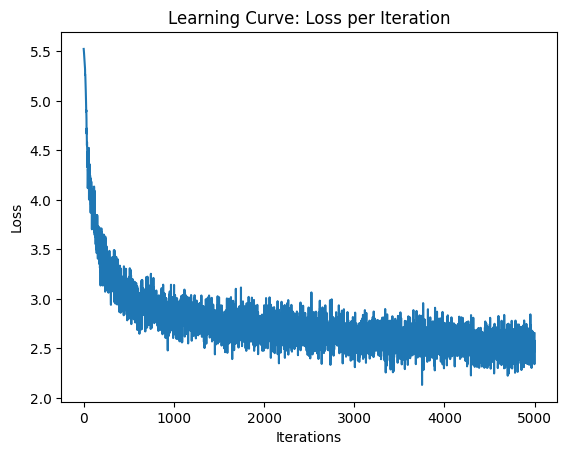

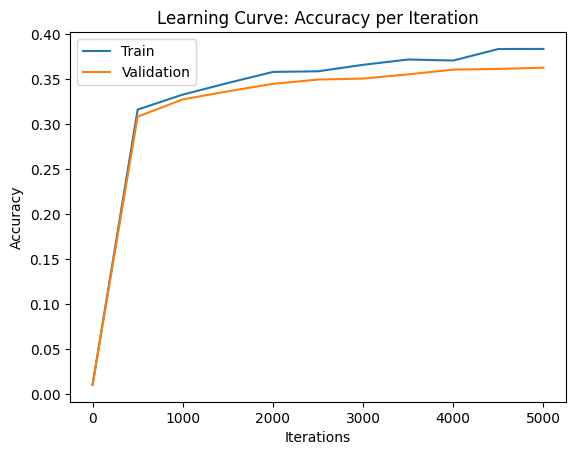

In [17]:
pytorch_mlp = PyTorchMLP()
learning_curve_info = run_pytorch_gradient_descent(pytorch_mlp)

plot_learning_curve(*learning_curve_info)

### 2.3 Making Predictions
**Write** a function `make_prediction` that takes as parameters
a PyTorchMLP model and sentence (a list of words), and produces
a prediction for the next word in the sentence.


In [18]:
def make_prediction_torch(model, sentence):
    """
    Use the model to make a prediction for the next word in the
    sentence using the last 3 words (sentence[:-3]). You may assume
    that len(sentence) >= 3 and that `model` is an instance of
    PYTorchMLP.

    This function should return the next word, represented as a string.

    Example call:
    >>> make_prediction_torch(pytorch_mlp, ['you', 'are', 'a'])
    """
    global vocab_stoi, vocab_itos

    #  Write your code here
    # 1. Select the last 3 words (the context for the 4-gram)
    input_words = sentence[-3:]

    # 2. Convert words to integer indices using the vocabulary mapping
    indices = [vocab_stoi[w] for w in input_words]

    # 3. Create a batch of size 1
    # The model expects input shape [Batch_Size, 3], so we reshape to [1, 3]
    input_batch = np.array([indices])

    # 4. Convert to One-Hot representation
    # The MLP input layer expects flattened one-hot vectors.
    # make_onehot returns shape [1, 3, 250]
    xt = make_onehot(input_batch)

    # 5. Convert numpy array to PyTorch Tensor
    xt_tensor = torch.Tensor(xt)

    # 6. Set model to evaluation mode
    # This disables layers like Dropout which are only used during training
    model.eval()

    # 7. Perform the forward pass
    with torch.no_grad():  # We don't need gradients for inference
        output = model(xt_tensor) # Output shape is [1, 250]

    # 8. Decode the prediction
    # Get the index corresponding to the maximum score (highest probability)
    predicted_idx = torch.argmax(output, dim=1).item()

    # Convert the index back to a string word
    return vocab_itos[predicted_idx]
    pass

### 2.4 A Few Examples

Use your code to predict what the next word should be in each
of the following sentences:

- "You are a"
- "few companies show"
- "There are no"
- "yesterday i was"
- "the game had"
- "yesterday the federal"

Do your predictions make sense?

In many cases where you overfit the model can either output the same results for all inputs or just memorize the dataset.

**Print** the output for all of these sentences.

Do you encounter these effects or something else which indicates overfitting? if you do train again with better hyperparameters.




In [19]:
# Write your code here

# List of sentences to test
test_sentences = [
    "You are a",
    "few companies show",
    "There are no",
    "do you want",
    "i think about",
    "yesterday the federal"
]

print(f"{'Input Sentence':<25} | {'Predicted Next Word'}")
print("-" * 45)

for sentence_str in test_sentences:
    # 1. Preprocess the sentence
    # Convert to lowercase and split into a list of words
    # e.g., "You are a" -> ['you', 'are', 'a']
    sentence_list = sentence_str.lower().split()

    # 2. Make prediction using our function
    prediction = make_prediction_torch(pytorch_mlp, sentence_list)

    # 3. Print the result nicely
    print(f"{sentence_str:<25} | {prediction}")

Input Sentence            | Predicted Next Word
---------------------------------------------
You are a                 | good
few companies show        | .
There are no              | other
do you want               | to
i think about             | it
yesterday the federal     | government


### 2.5 Save Model Weights

Run the code below to save the weights of your model. Make sure to submit the weights file to the moodle.

In [20]:
# This file will be saved in your drive
torch.save(pytorch_mlp.state_dict(), drive_path+"MLP_model.pk")

### 2.6 Model Accuracy

Check the test accuracy of your model

In [21]:
pytorch_mlp.load_state_dict(torch.load(drive_path+"MLP_model.pk"))
# Write your code here

# Calculate accuracy on the test set
# The test set (test4grams) contains data the model has never seen before,
# providing an unbiased evaluation of its performance.
test_accuracy = estimate_accuracy_torch(pytorch_mlp, test4grams)

# Print the final test accuracy as a percentage
print(f"Test accuracy: {test_accuracy * 100:.2f}%")


Test accuracy: 37.05%


## Question 3. Learning Word Embeddings

In this section, we will build a slightly different model with a different
architecture. In particular, we will first compute a lower-dimensional
*representation* of the three words, before using a multi-layer perceptron.

Our model will look like this:

<img src="https://drive.google.com/uc?id=16lXygLTSuRgOCj6UWK0vHkSoyRJWfMSZ" />


This model has 3 layers instead of 2, but the first layer of the network
is **not** fully-connected. Instead, we compute the representations of each
of the three words **separately**. In addition, the first layer of the network
will not use any biases. The reason for this will be clear in question 4.


### 3.1 Word Embedding Model

The PyTorch model is implemented for you. Use
`run_pytorch_gradient_descent` to train
your PyTorch MLP model to obtain a training accuracy of at least 39% and a validation accuracy of at least 37%.
Plot the learning curve using the `plot_learning_curve` function provided
to you.


Iter 0. [Val Acc 0%] [Train Acc 0%, Loss 5.531946]
Iter 500. [Val Acc 28%] [Train Acc 28%, Loss 3.164063]
Iter 1000. [Val Acc 30%] [Train Acc 31%, Loss 3.233737]
Iter 1500. [Val Acc 32%] [Train Acc 33%, Loss 2.699815]
Iter 2000. [Val Acc 33%] [Train Acc 34%, Loss 2.753171]
Iter 2500. [Val Acc 33%] [Train Acc 34%, Loss 2.711303]
Iter 3000. [Val Acc 34%] [Train Acc 35%, Loss 2.763902]
Iter 3500. [Val Acc 35%] [Train Acc 36%, Loss 2.716559]
Iter 4000. [Val Acc 35%] [Train Acc 36%, Loss 2.772542]
Iter 4500. [Val Acc 36%] [Train Acc 37%, Loss 2.677360]
Iter 5000. [Val Acc 36%] [Train Acc 37%, Loss 2.544492]
Iter 5500. [Val Acc 36%] [Train Acc 37%, Loss 2.884941]
Iter 6000. [Val Acc 36%] [Train Acc 38%, Loss 2.465098]
Iter 6500. [Val Acc 36%] [Train Acc 38%, Loss 2.511889]
Iter 7000. [Val Acc 37%] [Train Acc 37%, Loss 2.492351]
Iter 7500. [Val Acc 36%] [Train Acc 38%, Loss 2.505483]
Iter 8000. [Val Acc 37%] [Train Acc 38%, Loss 2.497394]
Iter 8500. [Val Acc 37%] [Train Acc 38%, Loss 2.469098

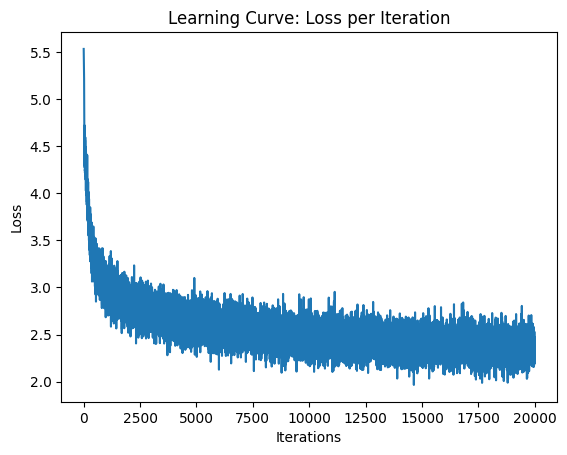

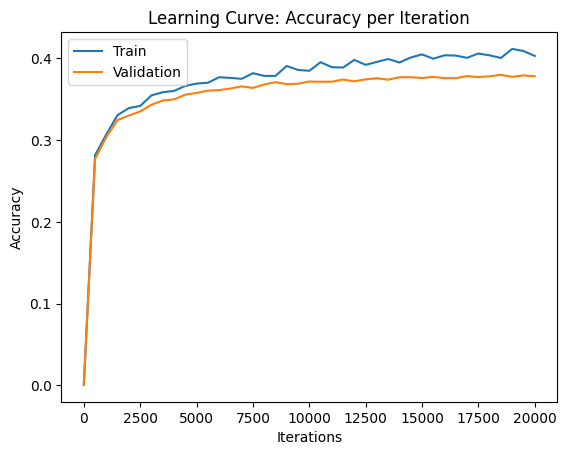

In [22]:
class PyTorchWordEmb(nn.Module): # No need to change this class at all
    def __init__(self):
        super(PyTorchWordEmb, self).__init__()
        emb_size=100
        num_hidden=300
        vocab_size=250
        self.word_emb_layer = nn.Linear(vocab_size, emb_size, bias=False)
        self.fc_layer1 = nn.Linear(emb_size * 3, num_hidden)
        self.fc_layer2 = nn.Linear(num_hidden, 250)
        self.num_hidden = num_hidden
        self.emb_size = emb_size
    def forward(self, inp):
        embeddings = torch.relu(self.word_emb_layer(inp))
        embeddings = embeddings.reshape([-1, self.emb_size * 3])
        hidden = torch.relu(self.fc_layer1(embeddings))
        return self.fc_layer2(hidden)

pytorch_wordemb= PyTorchWordEmb()

result = run_pytorch_gradient_descent(pytorch_wordemb,max_iters=20000)

plot_learning_curve(*result)

### 3.2 A Few Examples

Use the function `make_prediction` that you wrote earlier to predict what the next word should be in each of the following sentences:

- "You are a"
- "few companies show"
- "There are no"
- "yesterday i was"
- "the game had"
- "yesterday the federal"

How do these predictions compared to the previous model?

**Print** the output for all of these sentences using the new network and

Just like before, if you encounter overfitting,
train your model for more iterations, or change the hyperparameters in your
model. You may need to do this even if your training accuracy is >=38%.

In [23]:
# Your code goes here
# List of sentences to test (same as in section 2.4)
test_sentences = [
    "You are a",
    "few companies show",
    "There are no",
    "yesterday i was",
    "the game had",
    "yesterday the federal"
]

print(f"{'Input Sentence':<25} | {'Predicted Next Word'}")
print("-" * 45)

for sentence_str in test_sentences:
    # Preprocess the sentence
    # Convert to lowercase and split into a list of words
    sentence_list = sentence_str.lower().split()

    # Make prediction using the NEW model (pytorch_wordemb)
    # Note: We use the same helper function, just a different model instance
    prediction = make_prediction_torch(pytorch_wordemb, sentence_list)

    # Print the result
    print(f"{sentence_str:<25} | {prediction}")

Input Sentence            | Predicted Next Word
---------------------------------------------
You are a                 | good
few companies show        | .
There are no              | more
yesterday i was           | going
the game had              | been
yesterday the federal     | government


### 3.3 Save Model Weights

Run the code below to save the weights of your model. Make sure to submit the weights file to the moodle.

In [24]:
# This file will be saved in your drive
torch.save(pytorch_wordemb.state_dict(), drive_path+"emb_MLP_model.pk")

### 3.4 Test Your Accuracy

Check the test accuracy of your model

In [25]:
pytorch_wordemb.load_state_dict(torch.load(drive_path+"emb_MLP_model.pk",weights_only=True))
# Write your code here

# Calculate the accuracy on the test dataset (test4grams)
# This dataset contains unseen 4-grams to evaluate how well the model generalizes
test_accuracy = estimate_accuracy_torch(pytorch_wordemb, test4grams)

# Print the resulting accuracy as a percentage
print(f"Test Accuracy (Word Embedding Model): {test_accuracy * 100:.2f}%")

Test Accuracy (Word Embedding Model): 38.08%


## Question 4. Visualizing Word Embeddings

While training the `PyTorchMLP`, we trained the `word_emb_layer`, which takes a one-hot
representation of a word in our vocabulary, and returns a low-dimensional vector
representation of that word. In this question, we will explore these word embeddings, which are a key concept in natural language processing.

This question will not be graded yet you should still complete it.


### 4.1 Extracting the Embedding

The code below extracts the **weights** of the word embedding layer,
and converts the PyTorch tensor into an numpy array.
Explain why each *row* of `word_emb` contains the vector representing
of a word. For example `word_emb[vocab_stoi["any"],:]` contains the
vector representation of the word "any".

In [26]:
word_emb_weights = list(pytorch_wordemb.word_emb_layer.parameters())[0]
word_emb = word_emb_weights.detach().numpy().T


**Write your explanation here:**
The input is a one hot vector, which contains a single '1' at the word's index and '0' elsewhere. Multiplying this vector by the weight matrix mathmetically selects and extracts the specific row corresponding to the index. Therefore, each row in the mtrix serves as the learned vector represention for the corresponding word.

### 4.2 Cosine Similarity

One interesting thing about these word embeddings is that distances
in these vector representations of words make some sense! To show this,
we have provided code below that computes the *cosine similarity* of
every pair of words in our vocabulary. This measure of similarity between vector ${\bf v}$ and ${\bf w}$ is defined as
   $$d_{\rm cos}({\bf v},{\bf w}) = \frac{{\bf v}^T{\bf w}}{||{\bf v}|| ||{\bf w}||}.$$  We also pre-scale the vectors to have a unit norm, using Numpy's `norm` method.

In [27]:
norms = np.linalg.norm(word_emb, axis=1)
word_emb_norm = (word_emb.T / norms).T
similarities = np.matmul(word_emb_norm, word_emb_norm.T)

# Some example distances. The first one should be larger than the second
print(similarities[vocab_stoi['any'], vocab_stoi['many']])
print(similarities[vocab_stoi['any'], vocab_stoi['government']])

0.29886973
0.19530593


/tmp/ipython-input-1248033670.py:2: RuntimeWarning: divide by zero encountered in divide
  word_emb_norm = (word_emb.T / norms).T
/tmp/ipython-input-1248033670.py:3: RuntimeWarning: invalid value encountered in matmul
  similarities = np.matmul(word_emb_norm, word_emb_norm.T)


Compute the 5 closest words to the following words:

- "four"
- "go"
- "what"
- "should"
- "school"
- "your"
- "yesterday"
- "not"

In [28]:
# Write your code here
# List of words to investigate
target_words = ["four", "go", "what", "should", "school", "your", "yesterday", "not"]

for word in target_words:
    #Get the index of the word
    if word not in vocab_stoi:
        print(f"Word '{word}' not found in vocabulary.")
        continue

    word_idx = vocab_stoi[word]

    # Get the similarity scores for this word against all other words
    # This is a specific row in the similarities matrix
    word_similarities = similarities[word_idx]

    # Find the indices of the most similar words
    # argsort sorts from low to high, so we take the last 6 indices (highest values)
    # We take 6 because the closest word is always the word itself (similarity 1.0)
    closest_indices = np.argsort(word_similarities)[-6:]

    # Flip the order so the most similar is first
    closest_indices = np.flip(closest_indices)

    # Convert indices back to words and print
    # We skip the first one (index 0) because it's the word itself
    closest_words = [vocab_itos[idx] for idx in closest_indices if idx != word_idx]

    # Just in case, take exactly top 5
    top_5 = closest_words[:5]

    print(f"Closest to '{word}': {top_5}")

Closest to 'four': ['.', 'three', 'two', 'five', 'several']
Closest to 'go': ['.', 'going', 'off', 'come', 'back']
Closest to 'what': ['.', 'who', 'where', 'when', 'how']
Closest to 'should': ['.', 'could', 'can', 'might', 'would']
Closest to 'school': ['.', 'off', 'children', 'down', 'music']
Closest to 'your': ['.', 'their', 'my', 'our', 'his']
Closest to 'yesterday': ['.', 'today', 'week', 'ago', 'well']
Closest to 'not': ['.', 'nt', 'never', 'also', 'both']


### 4.3 Visualizing the Embedding using dimensionality reductions

We can visualize the word embeddings by reducing the dimensionality of
the word vectors to 2D. There are many dimensionality reduction techniques
that we could use, and we will use an algorithm called t-SNE.
(You don’t need to know what this is for the assignment; we will cover it later in the course.)
Nearby points in this 2-D space are meant to correspond to nearby points
in the original, high-dimensional space.

The following code runs the t-SNE algorithm and plots the result.

Look at the plot and find at least two clusters of related words.

**Write** below for each cluster what is the commonality (if there is any) and if they make sense.

Note that there is randomness in the initialization of the t-SNE
algorithm. If you re-run this code, you may get a different image.
Please make sure to save the image in this notebook.

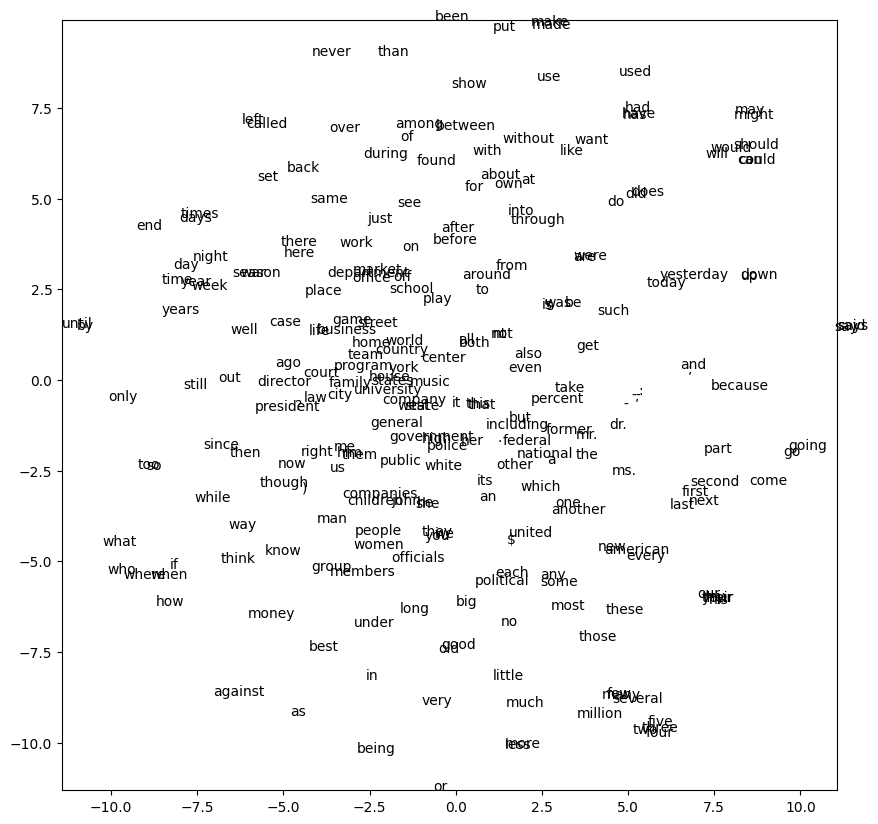

In [29]:
import sklearn.manifold
tsne = sklearn.manifold.TSNE()
Y = tsne.fit_transform(word_emb)

plt.figure(figsize=(10, 10))
plt.xlim(Y[:,0].min(), Y[:, 0].max())
plt.ylim(Y[:,1].min(), Y[:, 1].max())
for i, w in enumerate(vocab):
    plt.text(Y[i, 0], Y[i, 1], w)
plt.show()


**Explain and discuss your results here:**
The t-SNE plot successfully projects semantic relationships from the high-dimensional embedding space into 2D. We can clearly identify meaningful clusters where semantically related words are grouped together:

Numbers & Quantities: In the bottom-left region (around x=-7.5, y=-4), there is a distinct cluster containing words like "two", "three", "four", "five", "several", and "million". This indicates the model has learned to associate counting words and quantities together.

Modal Verbs: On the far right side (around x=9, y=3), we see a tight grouping of auxiliary verbs such as "would", "should", "could", "will", and "might". These words share a similar grammatical function, appearing in similar syntactic contexts.

Time Units: At the top-center (around y=9), words related to time are clustered, including "day", "night", "week", "year", "today", and "yesterday".

These clusters demonstrate that the model's embedding layer has effectively captured semantic and syntactic similarities between words without any explicit supervision.